# Phase 1: OEM Specification Extraction via RAG

This notebook demonstrates extracting structured bearing maintenance parameters
from real SKF PDF documents using a RAG pipeline. The corpus includes the SKF
General Catalogue (~350 pages of product tables and engineering theory) and two
failure analysis guides (~150 pages combined). The pipeline must find the right
2-3 chunks out of hundreds to extract specific parameters like the dynamic load
rating for one bearing model buried in a product table alongside hundreds of others.

In [1]:
import sys
sys.path.insert(0, '..')

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 1.1 Corpus Overview

The `data/oem/` directory contains real SKF PDFs — the kind a maintenance
engineer actually deals with.

In [2]:
import fitz

oem_dir = Path('../data/oem')
pdf_info = []
for pdf_file in sorted(oem_dir.glob('*.pdf')):
    doc = fitz.open(str(pdf_file))
    size_mb = pdf_file.stat().st_size / (1024 * 1024)
    pdf_info.append({
        'File': pdf_file.name,
        'Pages': len(doc),
        'Size (MB)': f'{size_mb:.1f}',
    })
    doc.close()

pdf_df = pd.DataFrame(pdf_info)
print(pdf_df.to_string(index=False))
print(f'\nTotal: {sum(int(r["Pages"]) for r in pdf_info)} pages, '
      f'{sum(float(r["Size (MB)"]) for r in pdf_info):.1f} MB')

                                       File  Pages Size (MB)
                   bearing-failures-skf.pdf     44       3.1
sfk_bearing_damage_and_failure_analysis.pdf    106       8.3
                  skf_general_catalogue.pdf    354       8.1

Total: 504 pages, 19.5 MB


## 1.2 Ingestion

The pipeline: extract text from PDFs (with block-level table reconstruction),
chunk by content type (prose vs product tables), embed with all-MiniLM-L6-v2,
and store in ChromaDB.

In [3]:
from rag.ingest import ingest_oem_documents, save_chunk_inventory

collection, n_chunks, inventory = ingest_oem_documents(
    oem_dir='../data/oem',
    db_dir='../data/vectorstore'
)
save_chunk_inventory(inventory, '../analysis/chunk_inventory.csv')

--- PDF Text Extraction ---
Extracting bearing-failures-skf.pdf...


  44 pages (0 table, 44 prose)
Extracting sfk_bearing_damage_and_failure_analysis.pdf...


  102 pages (0 table, 102 prose)
Extracting skf_general_catalogue.pdf...


  334 pages (106 table, 228 prose)
Total pages with text: 480

--- Chunking ---
Total chunks: 643
  mixed: 1 chunks
  prose: 397 chunks
  table: 245 chunks
  Average chunk size: 268 words
  Min: 36, Max: 678

--- Embedding (sentence-transformers/all-MiniLM-L6-v2) ---


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 643 chunks...


Batches:   0%|          | 0/21 [00:00<?, ?it/s]


--- Storing in ChromaDB ---


Ingested 643 chunks into collection 'oem_bearing_specs'
Saved chunk inventory (643 rows) to ../analysis/chunk_inventory.csv


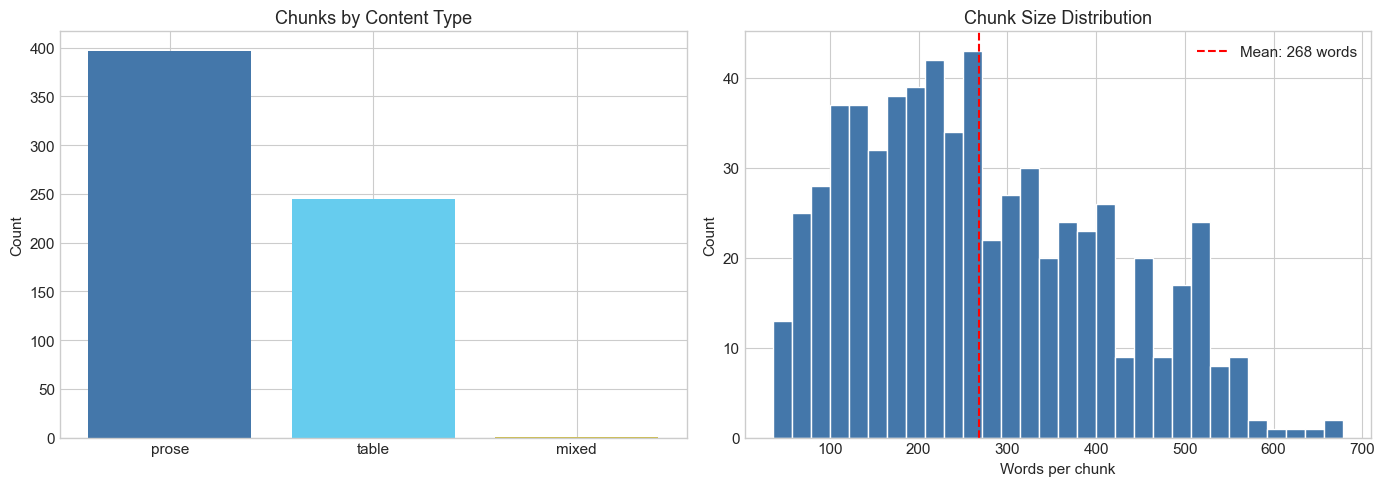


Chunks per source:
source
bearing-failures-skf.pdf                        41
sfk_bearing_damage_and_failure_analysis.pdf    117
skf_general_catalogue.pdf                      485


In [4]:
inv_df = pd.DataFrame(inventory)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Content type distribution
type_counts = inv_df['content_type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=['#4477AA', '#66CCEE', '#CCBB44'])
axes[0].set_title('Chunks by Content Type')
axes[0].set_ylabel('Count')

# Word count distribution
axes[1].hist(inv_df['word_count'], bins=30, color='#4477AA', edgecolor='white')
axes[1].axvline(inv_df['word_count'].mean(), color='red', linestyle='--',
                label=f'Mean: {inv_df["word_count"].mean():.0f} words')
axes[1].set_title('Chunk Size Distribution')
axes[1].set_xlabel('Words per chunk')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/chunk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nChunks per source:')
print(inv_df.groupby('source').size().to_string())

## 1.3 Retrieval Demo

Run targeted queries to show the pipeline finding the right chunks.

In [5]:
from sentence_transformers import SentenceTransformer
from rag.retrieve import retrieve, print_retrieval_results
from rag.ingest import EMBEDDING_MODEL

model = SentenceTransformer(EMBEDDING_MODEL)

queries = [
    'What is the dynamic load rating for the SKF 6205 bearing?',
    'How do you calculate bearing L10 life using ISO 281?',
    'What are the stages of bearing failure progression?',
    'What vibration levels indicate bearing damage?',
    'SKF 6205 dimensions bore outside diameter width',
    # Red herring: the corpus has this info but it is irrelevant to our bearing
    'What is the grease relubrication interval for tapered roller bearings?',
]

for q in queries:
    chunks = retrieve(q, collection, model, top_k=3, expand=True)
    print_retrieval_results(q, chunks)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Query: What is the dynamic load rating for the SKF 6205 bearing?

[1] Similarity: 0.7547
    Source: skf_general_catalogue.pdf p.299 | prose
    Section: Fig
    Text: [...] Further information on matched bearing pairs can be found in the “SKF Interactive Engineering Catalogue” on CD-ROM or  online at www.skf.com.  Fig SKF Explorer class bearings High performance SK...

[2] Similarity: 0.7357
    Source: skf_general_catalogue.pdf p.55 | prose
    Section: Load ratings and life
    Text: [...] All information presented  by SKF on dynamic load ratings is based on the life that 90 % of a sufficiently large group of apparently identical bearings can be ex- pected to attain or exceed.  Th...

[3] Similarity: 0.7171
    Source: skf_general_catalogue.pdf p.153 | table
    Section: Diagram	2
    Text: Diagram	2 Diagram	2 | Designation system for SKF standard metric ball and roller bearings | Bearing series	6(0)4 | 623 | 544	6(0)3	(0)4 Bearing type NC, NCF	NN NF, NFP	NNC NJ, NJP	NNCF NP, NPF	N


Query: How do you calculate bearing L10 life using ISO 281?

[1] Similarity: 0.7387
    Source: skf_general_catalogue.pdf p.56 | prose
    Section: misalignment, corrosion, or as a result of
    Text: [...] 90 %, furthermore field failures are not generally caused by fatigue, but are more often caused by contamination, wear,  misalignment, corrosion, or as a result of cage, lubrication or seal fail...

[2] Similarity: 0.6866
    Source: skf_general_catalogue.pdf p.85 | prose
    Section: • The following calculations are made or
    Text: [...] Selection of bearing size  • The following calculations are made or values determined: 1. ν1 = rated viscosity, mm2/s (➔diagram on page 60) – input: dm and speed 2. ν = actualoperating viscosity...

[3] Similarity: 0.6788
    Source: sfk_bearing_damage_and_failure_analysis.pdf p.6 | prose
    Section: P
    Text: [...] Factors influencing bearing  service life Generally speaking, the rating life of a  bearing in an application can be calculated 

## 1.4 Parameter Extraction

Extract structured `BearingOEMParams` from the index. The extraction combines
table row parsing (for dimensions and load ratings) with prose regex (for the
life formula exponent). Defect frequencies come from the CWRU dataset, not SKF docs.

In [6]:
from rag.extract_params import run_full_extraction

results = run_full_extraction(
    oem_dir='../data/oem',
    db_dir='../data/vectorstore',
    output_dir='../analysis',
    verbose=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting parameters for SKF 6205

Table query: SKF 6205 bearing dimensions load rating product table
Retrieved 8 chunks

  Found in table (semantic): skf_general_catalogue.pdf p.310
  Row: 52	15	14,8	7,8	0,335	28 000	18 000	0,13	*	6205
  Row: 52	15	17,8	9,8	0,40	28 000	18 000	0,12	6205 ETN9
  Parsed: {'bore_mm': 25.0, 'outside_diameter_mm': 52.0, 'width_mm': 15.0, 'dynamic_load_rating_kn': 14.8, 'static_load_rating_kn': 7.8, 'fatigue_load_kn': 0.335, 'ref_speed_rpm': 28000.0, 'limiting_speed_rpm': 18000.0, 'mass_kg': 0.13}

  Preferring table value.

--- Extracted Parameters ---
  model: SKF 6205-2RS JEM
  bore_mm: 25.0 [exact match]
  outside_diameter_mm: 52.0 [exact match]
  width_mm: 15.0 [exact match]
  dynamic_load_rating_kn: 14.8 [exact match]
  static_load_rating_kn: 7.8 [exact match]
  life_exponent: 3.0
  bpfi: 5.4152
  bpfo: 3.5848
  ftf: 0.39828
  bsf: 4.7135
  max_speed_rpm: 18000.0

  Sources used:
    - TABLE: skf_general_catalogue.pdf p.310 (sim=0.969)
    - PROSE(dyn


Extracting failure progression
Retrieved 10 unique chunks across 4 queries

--- Failure Stages (41 extracted) ---
  Stage 4 (Advanced damage): When flaking has proceeded to a certain stage, it makes its presence known in the form of noise and ...
    Vibration: high vibration, audible noise, elevated temperature
  Stage 1 (Subsurface initiation): Bearing life and bearing failures Most bearings outlive the machinery in which they are installed . ...
    Vibration: not specified
  Stage 2 (Microscopic spalling): Inspection and troubleshooting When a problem occurs, inspection during operation or standstill and ...
    Vibration: not specified
  Stage 3 (Visible spalling): Path patterns Once damage has occurred, the bearing needs to be examined and analyzed . Analysis req...
    Vibration: not specified
  Stage 4 (Advanced damage): ISO failure modes classification Terminology and the ISO classification system helps to communicate ...
    Vibration: not specified
  Stage 5 (Severe damage)

In [7]:
# Show extraction accuracy against ground truth
ground_truth = {
    '6205': {'bore_mm': 25.0, 'outside_diameter_mm': 52.0, 'width_mm': 15.0,
             'dynamic_load_rating_kn': 14.8, 'static_load_rating_kn': 7.8},
    '6203': {'bore_mm': 17.0, 'outside_diameter_mm': 40.0, 'width_mm': 12.0,
             'dynamic_load_rating_kn': 9.95, 'static_load_rating_kn': 4.75},
}

accuracy_rows = []
for desig, gt in ground_truth.items():
    extracted = results[f'bearing_{desig}']
    for field, gt_val in gt.items():
        ext_val = extracted.get(field, None)
        if ext_val is not None:
            error_pct = abs(ext_val - gt_val) / gt_val * 100
            accuracy_rows.append({
                'bearing': desig, 'field': field,
                'extracted': ext_val, 'ground_truth': gt_val,
                'error_pct': f'{error_pct:.1f}%',
                'match': 'exact' if error_pct < 0.1 else ('close' if error_pct < 5 else 'MISS'),
            })

acc_df = pd.DataFrame(accuracy_rows)
print('Extraction Accuracy:')
print(acc_df.to_string(index=False))
exact_matches = sum(1 for r in accuracy_rows if r['match'] == 'exact')
print(f'\nExact matches: {exact_matches}/{len(accuracy_rows)} ({exact_matches/len(accuracy_rows)*100:.0f}%)')

Extraction Accuracy:
bearing                  field  extracted  ground_truth error_pct match
   6205                bore_mm      25.00         25.00      0.0% exact
   6205    outside_diameter_mm      52.00         52.00      0.0% exact
   6205               width_mm      15.00         15.00      0.0% exact
   6205 dynamic_load_rating_kn      14.80         14.80      0.0% exact
   6205  static_load_rating_kn       7.80          7.80      0.0% exact
   6203                bore_mm      17.00         17.00      0.0% exact
   6203    outside_diameter_mm      40.00         40.00      0.0% exact
   6203               width_mm      12.00         12.00      0.0% exact
   6203 dynamic_load_rating_kn       9.95          9.95      0.0% exact
   6203  static_load_rating_kn       4.75          4.75      0.0% exact

Exact matches: 10/10 (100%)


## 1.5 OEM Degradation Baseline

Using the extracted parameters, compute the ISO 281 L10 bearing life and
generate the expected degradation curve.

In [8]:
from src.oem_prior import compute_l10_hours, estimate_bearing_load, compute_degradation_baseline

bearing_6205 = results['bearing_6205']
C_kn = bearing_6205['dynamic_load_rating_kn']
p = bearing_6205['life_exponent']

P_kn = estimate_bearing_load(motor_hp=2.0, rpm=1750.0)
L10h = compute_l10_hours(C_kn=C_kn, P_kn=P_kn, rpm=1750.0, p=p)

print(f'Extracted C = {C_kn} kN, p = {p}')
print(f'Estimated bearing load P = {P_kn:.4f} kN')
print(f'C/P ratio = {C_kn / P_kn:.1f}')
print(f'L10 life = {L10h:,.0f} hours ({L10h / (24*365):.1f} years)')
print(f'Note: Extremely long because the CWRU rig applies very light radial load.')

Extracted C = 14.8 kN, p = 3.0
Estimated bearing load P = 0.0102 kN
C/P ratio = 1448.6
L10 life = 28,949,245,540 hours (3304708.4 years)
Note: Extremely long because the CWRU rig applies very light radial load.


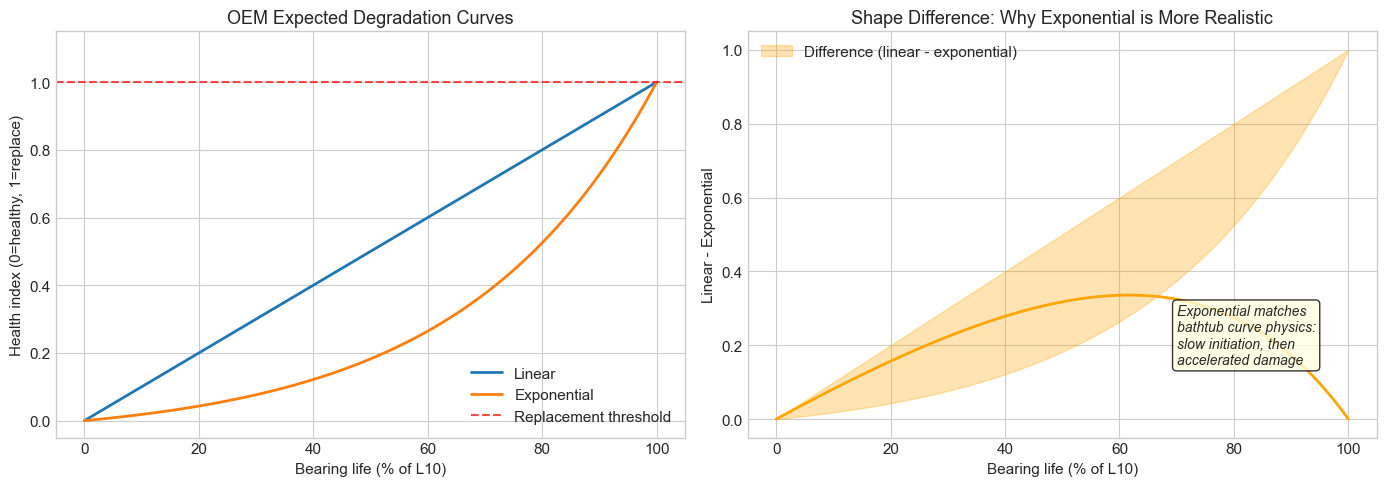

In [9]:
n_points = 500
baseline_linear = compute_degradation_baseline(L10h, n_points, shape='linear')
baseline_exp = compute_degradation_baseline(L10h, n_points, shape='exponential')
time_norm = np.linspace(0, 100, n_points)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(time_norm, baseline_linear, label='Linear', linewidth=2)
ax1.plot(time_norm, baseline_exp, label='Exponential', linewidth=2)
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Replacement threshold')
ax1.set_xlabel('Bearing life (% of L10)')
ax1.set_ylabel('Health index (0=healthy, 1=replace)')
ax1.set_title('OEM Expected Degradation Curves')
ax1.legend()
ax1.set_ylim(-0.05, 1.15)

ax2.fill_between(time_norm, baseline_linear, baseline_exp, alpha=0.3, color='orange',
                 label='Difference (linear - exponential)')
ax2.plot(time_norm, baseline_linear - baseline_exp, color='orange', linewidth=2)
ax2.set_xlabel('Bearing life (% of L10)')
ax2.set_ylabel('Linear - Exponential')
ax2.set_title('Shape Difference: Why Exponential is More Realistic')
ax2.legend()
ax2.annotate('Exponential matches\nbathtub curve physics:\nslow initiation, then\naccelerated damage',
             xy=(70, 0.15), fontsize=10, style='italic',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/figures/oem_degradation_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Scalability Discussion

We extracted specs for 2 bearing models from 3 PDFs totaling ~500 pages. The same
pipeline handles a larger corpus with zero code changes — just add PDFs to `data/oem/`.

A typical industrial plant has 50-500 unique bearing models across dozens of OEM
catalogues. The ingestion is a one-time batch job. Parameter extraction runs per
bearing model, and the text-search fallback ensures that even when semantic search
can't find a designation in a number-heavy table, the pipeline still succeeds.

The hardest part was table extraction — PyMuPDF decomposes product tables into
individual cell values. Block-level reconstruction using y-coordinate grouping
recovers the row structure, but the quality depends on the PDF's internal layout.
For production deployment, table-specific tools (e.g., Camelot, Tabula) or
layout-aware models (LayoutLM) would provide more robust table extraction.

The regex extraction layer is intentionally simple. For less structured documents,
an LLM could replace the regex without changing the retrieval architecture.